In [1]:
# importing the libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')


In [2]:
# importing sklearn libraries
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import(
    accuracy_score,
    recall_score,
    precision_score,
    f1_score,
    classification_report,
    confusion_matrix
)

In [3]:
# reading the dataset
data = pd.read_csv('PS_20174392719_1491204439457_log.csv')

In [4]:
df = data.copy()

In [5]:
df.head()

,step,type,amount,nameOrig,oldbalanceOrg,newbalanceOrig,nameDest,oldbalanceDest,newbalanceDest,isFraud,isFlaggedFraud
0,1,PAYMENT,9839.64,C1231006815,170136.0,160296.36,M1979787155,0.0,0.0,0,0
1,1,PAYMENT,1864.28,C1666544295,21249.0,19384.72,M2044282225,0.0,0.0,0,0
2,1,TRANSFER,181.00,C1305486145,181.0,0.00,C553264065,0.0,0.0,1,0
3,1,CASH_OUT,181.00,C840083671,181.0,0.00,C38997010,21182.0,0.0,1,0
4,1,PAYMENT,11668.14,C2048537720,41554.0,29885.86,M1230701703,0.0,0.0,0,0


In [6]:
df.tail()

,step,type,amount,nameOrig,oldbalanceOrg,newbalanceOrig,nameDest,oldbalanceDest,newbalanceDest,isFraud,isFlaggedFraud
6362615,743,CASH_OUT,339682.13,C786484425,339682.13,0.0,C776919290,0.00,339682.13,1,0
6362616,743,TRANSFER,6311409.28,C1529008245,6311409.28,0.0,C1881841831,0.00,0.00,1,0
6362617,743,CASH_OUT,6311409.28,C1162922333,6311409.28,0.0,C1365125890,68488.84,6379898.11,1,0
6362618,743,TRANSFER,850002.52,C1685995037,850002.52,0.0,C2080388513,0.00,0.00,1,0
6362619,743,CASH_OUT,850002.52,C1280323807,850002.52,0.0,C873221189,6510099.11,7360101.63,1,0


In [7]:
df.shape

(6362620, 11)

In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6362620 entries, 0 to 6362619
Data columns (total 11 columns):
 #   Column          Dtype  
---  ------          -----  
 0   step            int64  
 1   type            object 
 2   amount          float64
 3   nameOrig        object 
 4   oldbalanceOrg   float64
 5   newbalanceOrig  float64
 6   nameDest        object 
 7   oldbalanceDest  float64
 8   newbalanceDest  float64
 9   isFraud         int64  
 10  isFlaggedFraud  int64  
dtypes: float64(5), int64(3), object(3)
memory usage: 534.0+ MB


- There are 4 object type columns, all the columns which indicates the money are in float.
- Three columns are int type.

In [9]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
step,6362620.0,2.433972e+02,1.423320e+02,1.0,156.00,239.000,3.350000e+02,7.430000e+02
amount,6362620.0,1.798619e+05,6.038582e+05,0.0,13389.57,74871.940,2.087215e+05,9.244552e+07
oldbalanceOrg,6362620.0,8.338831e+05,2.888243e+06,0.0,0.00,14208.000,1.073152e+05,5.958504e+07
newbalanceOrig,6362620.0,8.551137e+05,2.924049e+06,0.0,0.00,0.000,1.442584e+05,4.958504e+07
oldbalanceDest,6362620.0,1.100702e+06,3.399180e+06,0.0,0.00,132705.665,9.430367e+05,3.560159e+08
newbalanceDest,6362620.0,1.224996e+06,3.674129e+06,0.0,0.00,214661.440,1.111909e+06,3.561793e+08
isFraud,6362620.0,1.290820e-03,3.590480e-02,0.0,0.00,0.000,0.000000e+00,1.000000e+00
isFlaggedFraud,6362620.0,2.514687e-06,1.585775e-03,0.0,0.00,0.000,0.000000e+00,1.000000e+00


In [10]:
df['isFraud'].value_counts()

0    6354407
1       8213
Name: isFraud, dtype: int64

- There are total 8213 fraud transactions.

In [11]:
df['isFlaggedFraud'].value_counts()

0    6362604
1         16
Name: isFlaggedFraud, dtype: int64

- There are only 16 flaggedfraud as per the data.

In [12]:
df.isnull().sum()

step              0
type              0
amount            0
nameOrig          0
oldbalanceOrg     0
newbalanceOrig    0
nameDest          0
oldbalanceDest    0
newbalanceDest    0
isFraud           0
isFlaggedFraud    0
dtype: int64

- There are no missing values.

In [13]:
df.duplicated().sum()

0

- There are no duplicate values

## Explanatory Data Analysis

<Axes: xlabel='step', ylabel='Count'>

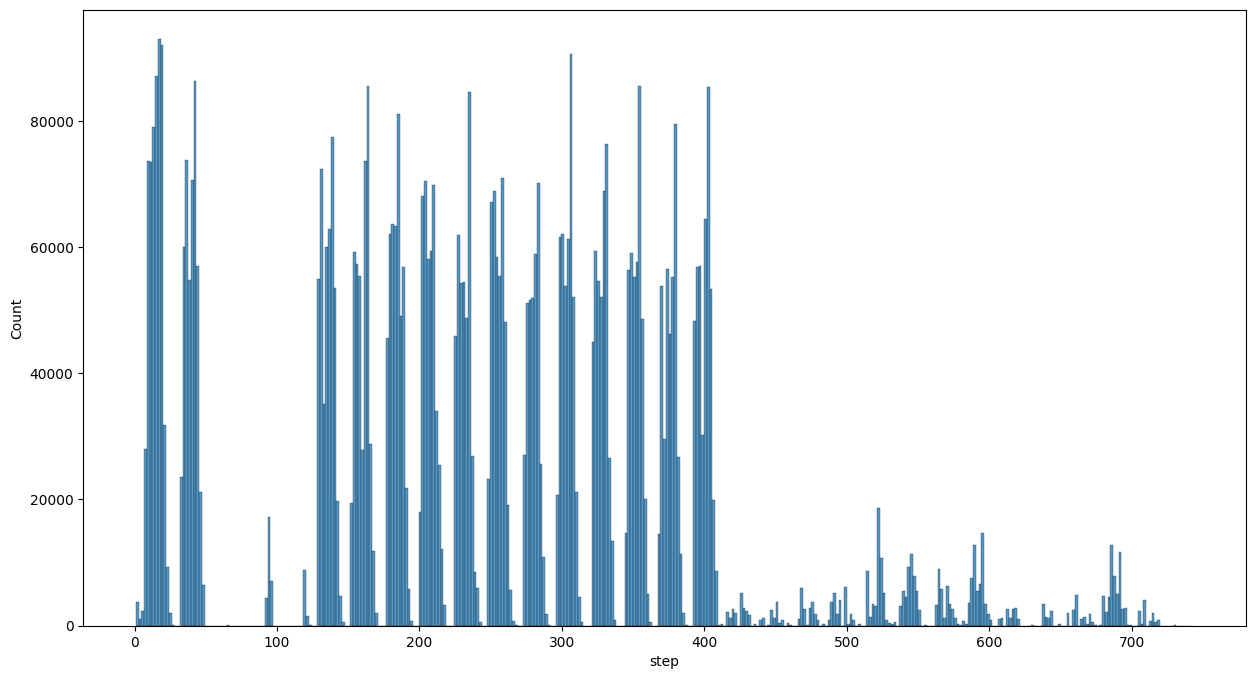

In [14]:
# Distribution for the step
plt.figure(figsize = (15,8))
sns.histplot(data=df, x= 'step')

<Axes: xlabel='type', ylabel='Count'>

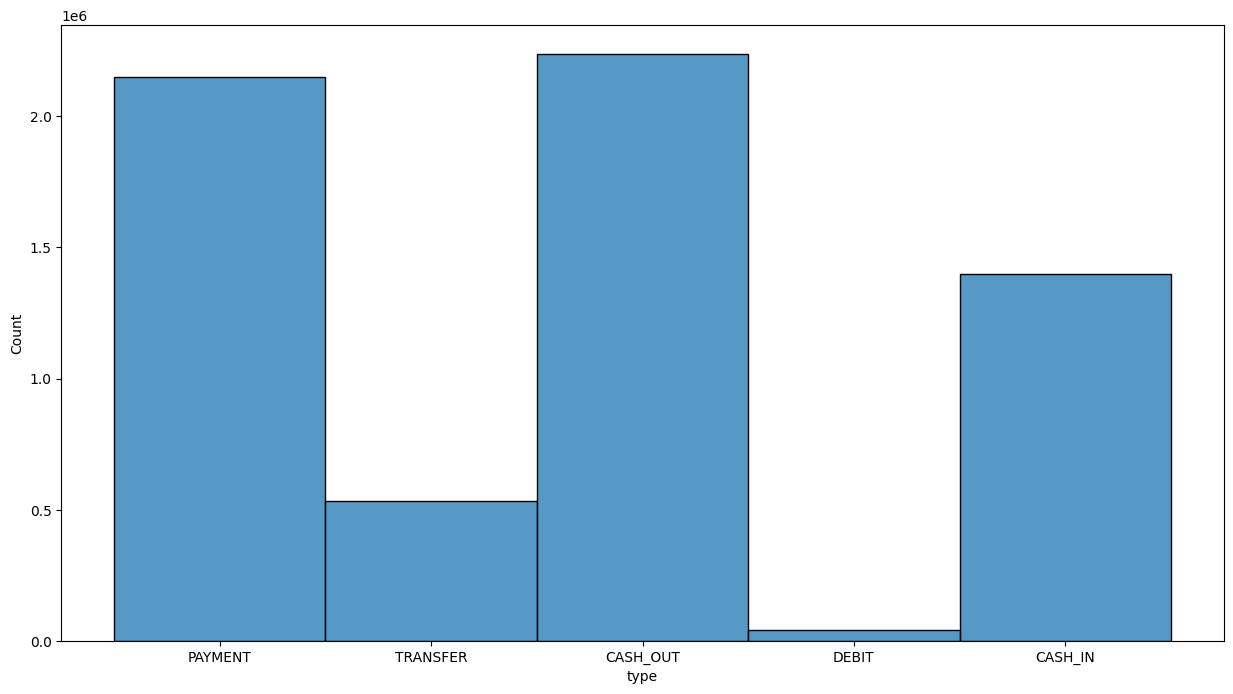

In [15]:
# Distribution for the type
plt.figure(figsize = (15,8))
sns.histplot(data= df, x = 'type')

- CASH_OUT and PAYMENT  is used more than the other types.

In [16]:
# Checking the fraud as per the type
pd.crosstab(df['type'], df['isFraud'])

isFraud,0,1
type,,
CASH_IN,1399284,0
CASH_OUT,2233384,4116
DEBIT,41432,0
PAYMENT,2151495,0
TRANSFER,528812,4097


<Axes: xlabel='type', ylabel='count'>

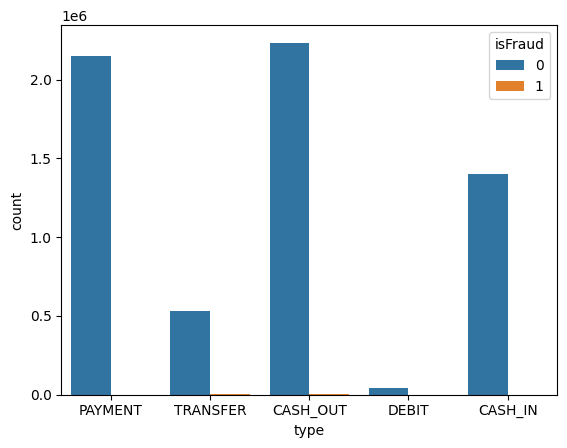

In [17]:
sns.countplot(data=df, x = 'type', hue = 'isFraud')

<Axes: xlabel='amount', ylabel='Count'>

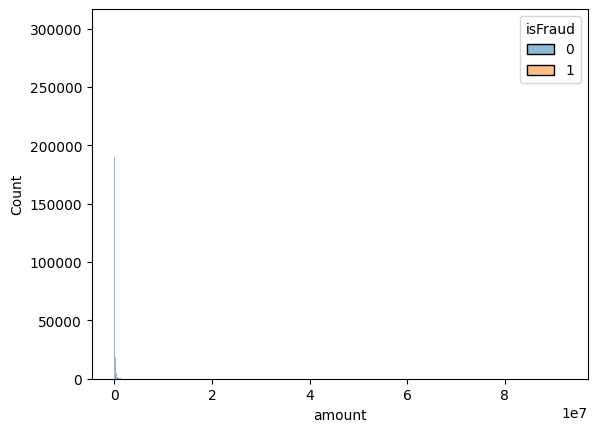

In [18]:
sns.histplot(data=df, x = 'amount', hue = 'isFraud')

<Axes: xlabel='isFraud', ylabel='amount'>

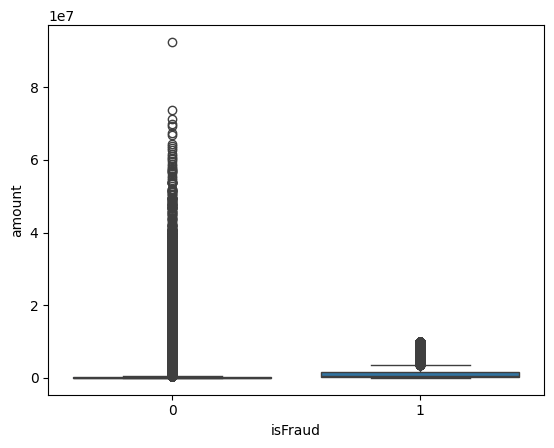

In [19]:
sns.boxplot(data=df, x = 'isFraud', y = 'amount')

In [20]:
fraud_by_hour = (
    df.groupby('step')['isFraud'].sum()
)

<Axes: xlabel='step'>

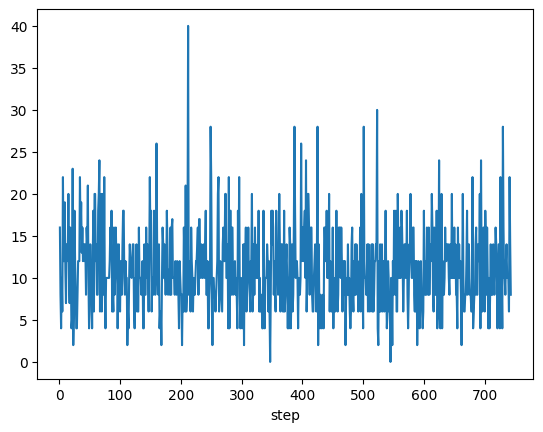

In [21]:
fraud_by_hour.plot()

<Axes: >

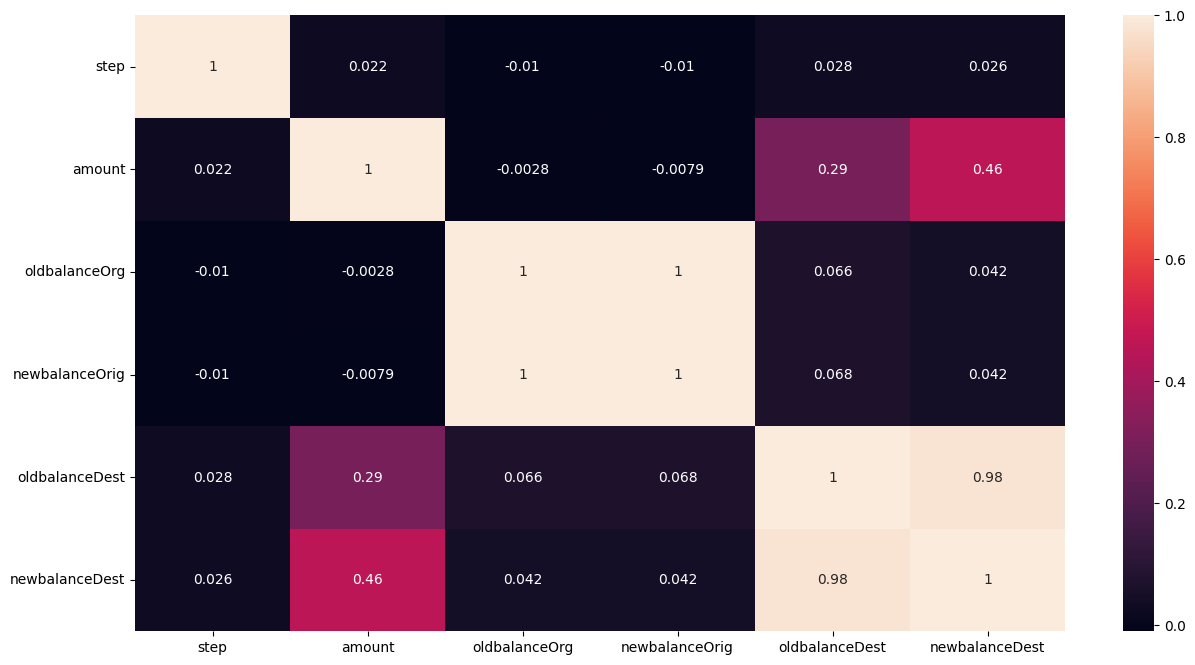

In [22]:
num_cols = ['step', 'amount', 'oldbalanceOrg', 'newbalanceOrig', 'oldbalanceDest', 'newbalanceDest']
plt.figure(figsize = (15,8))
sns.heatmap(df[num_cols].corr(), annot = True)

- newbalanceDest and amount has highest positive correlation of 0.46.
- oldbalanceDest and amount has positive correlation of 0.29.

## Fraud relation from the perspective of all the other parameters

In [23]:
fraud_df = df[df['isFraud']==1]

In [24]:
fraud_df['type'].value_counts()

CASH_OUT    4116
TRANSFER    4097
Name: type, dtype: int64

- Cash_out and Transfer has almost the same number of fraud detections.

In [25]:
pd.set_option('display.float_format', '{:,.2f}'.format)
fraud_df['amount'].describe()

count        8,213.00
mean     1,467,967.30
std      2,404,252.95
min              0.00
25%        127,091.33
50%        441,423.44
75%      1,517,771.48
max     10,000,000.00
Name: amount, dtype: float64

In [26]:
fraud_df['step'].describe()

count   8,213.00
mean      368.41
std       216.39
min         1.00
25%       181.00
50%       367.00
75%       558.00
max       743.00
Name: step, dtype: float64

In [27]:
fraud_df[
    df['oldbalanceOrg']==0
    ]

,step,type,amount,nameOrig,oldbalanceOrg,newbalanceOrig,nameDest,oldbalanceDest,newbalanceDest,isFraud,isFlaggedFraud
724,1,CASH_OUT,"416,001.33",C749981943,0.00,0.00,C667346055,102.00,"9,291,619.62",1,0
14861,8,CASH_OUT,"181,728.11",C2102265902,0.00,0.00,C789014007,"11,397.00","184,477.77",1,0
25875,8,TRANSFER,"1,078,013.76",C1026280121,0.00,0.00,C277510102,0.00,"970,749.68",1,0
77745,10,CASH_OUT,"277,970.88",C489647033,0.00,0.00,C571514738,0.00,"277,970.88",1,0
138559,11,TRANSFER,"1,933,920.80",C1706582969,0.00,0.00,C461905695,"1,283,762.85","3,217,683.65",1,0
169998,12,CASH_OUT,"149,668.66",C227115333,0.00,0.00,C460735540,"44,170.11","193,838.76",1,0
178668,12,CASH_OUT,"222,048.71",C265790428,0.00,0.00,C1700442291,"2,979.00","225,027.71",1,0
200845,13,CASH_OUT,"454,859.39",C1274887619,0.00,0.00,C2146670328,0.00,"454,859.39",1,0
291459,15,CASH_OUT,"95,428.32",C947728507,0.00,0.00,C1720721903,0.00,"95,428.32",1,0
296686,15,CASH_OUT,"39,713.28",C1404885898,0.00,0.00,C1795377601,"1,274,866.51","1,314,579.79",1,0


In [28]:
fraud_df[
    df['oldbalanceDest']==0
    ]

,step,type,amount,nameOrig,oldbalanceOrg,newbalanceOrig,nameDest,oldbalanceDest,newbalanceDest,isFraud,isFlaggedFraud
2,1,TRANSFER,181.00,C1305486145,181.00,0.00,C553264065,0.00,0.00,1,0
251,1,TRANSFER,"2,806.00",C1420196421,"2,806.00",0.00,C972765878,0.00,0.00,1,0
680,1,TRANSFER,"20,128.00",C137533655,"20,128.00",0.00,C1848415041,0.00,0.00,1,0
969,1,TRANSFER,"1,277,212.77",C1334405552,"1,277,212.77",0.00,C431687661,0.00,0.00,1,0
970,1,CASH_OUT,"1,277,212.77",C467632528,"1,277,212.77",0.00,C716083600,0.00,"2,444,985.19",1,0
...,...,...,...,...,...,...,...,...,...,...,...
6362612,743,TRANSFER,"1,258,818.82",C1531301470,"1,258,818.82",0.00,C1470998563,0.00,0.00,1,0
6362614,743,TRANSFER,"339,682.13",C2013999242,"339,682.13",0.00,C1850423904,0.00,0.00,1,0
6362615,743,CASH_OUT,"339,682.13",C786484425,"339,682.13",0.00,C776919290,0.00,"339,682.13",1,0
6362616,743,TRANSFER,"6,311,409.28",C1529008245,"6,311,409.28",0.00,C1881841831,0.00,0.00,1,0


In [29]:
fraud_df[
    df['newbalanceDest']==0
]

,step,type,amount,nameOrig,oldbalanceOrg,newbalanceOrig,nameDest,oldbalanceDest,newbalanceDest,isFraud,isFlaggedFraud
2,1,TRANSFER,181.00,C1305486145,181.00,0.00,C553264065,0.00,0.00,1,0
3,1,CASH_OUT,181.00,C840083671,181.00,0.00,C38997010,"21,182.00",0.00,1,0
251,1,TRANSFER,"2,806.00",C1420196421,"2,806.00",0.00,C972765878,0.00,0.00,1,0
252,1,CASH_OUT,"2,806.00",C2101527076,"2,806.00",0.00,C1007251739,"26,202.00",0.00,1,0
680,1,TRANSFER,"20,128.00",C137533655,"20,128.00",0.00,C1848415041,0.00,0.00,1,0
...,...,...,...,...,...,...,...,...,...,...,...
6362610,742,TRANSFER,"63,416.99",C778071008,"63,416.99",0.00,C1812552860,0.00,0.00,1,0
6362612,743,TRANSFER,"1,258,818.82",C1531301470,"1,258,818.82",0.00,C1470998563,0.00,0.00,1,0
6362614,743,TRANSFER,"339,682.13",C2013999242,"339,682.13",0.00,C1850423904,0.00,0.00,1,0
6362616,743,TRANSFER,"6,311,409.28",C1529008245,"6,311,409.28",0.00,C1881841831,0.00,0.00,1,0


In [30]:
fraud_df[
    df['newbalanceOrig']==0
]

,step,type,amount,nameOrig,oldbalanceOrg,newbalanceOrig,nameDest,oldbalanceDest,newbalanceDest,isFraud,isFlaggedFraud
2,1,TRANSFER,181.00,C1305486145,181.00,0.00,C553264065,0.00,0.00,1,0
3,1,CASH_OUT,181.00,C840083671,181.00,0.00,C38997010,"21,182.00",0.00,1,0
251,1,TRANSFER,"2,806.00",C1420196421,"2,806.00",0.00,C972765878,0.00,0.00,1,0
252,1,CASH_OUT,"2,806.00",C2101527076,"2,806.00",0.00,C1007251739,"26,202.00",0.00,1,0
680,1,TRANSFER,"20,128.00",C137533655,"20,128.00",0.00,C1848415041,0.00,0.00,1,0
...,...,...,...,...,...,...,...,...,...,...,...
6362615,743,CASH_OUT,"339,682.13",C786484425,"339,682.13",0.00,C776919290,0.00,"339,682.13",1,0
6362616,743,TRANSFER,"6,311,409.28",C1529008245,"6,311,409.28",0.00,C1881841831,0.00,0.00,1,0
6362617,743,CASH_OUT,"6,311,409.28",C1162922333,"6,311,409.28",0.00,C1365125890,"68,488.84","6,379,898.11",1,0
6362618,743,TRANSFER,"850,002.52",C1685995037,"850,002.52",0.00,C2080388513,0.00,0.00,1,0


- The fraud is detected even when the oldbalanceOrg, oldbalanceDest, newbalanceOrig, newbalanceDest is 0.

In [31]:
df['balancediff_Org'] = df['oldbalanceOrg'] - df['newbalanceOrig']
#pd.set_option('display.width', 1000)
#print(df['balancediff_Org'].head(100).to_string(index=False))
df['balancediff_Org']

0             9,839.64
1             1,864.28
2               181.00
3               181.00
4            11,668.14
              ...     
6362615     339,682.13
6362616   6,311,409.28
6362617   6,311,409.28
6362618     850,002.52
6362619     850,002.52
Name: balancediff_Org, Length: 6362620, dtype: float64

In [32]:
df['balancediff_Dest'] = df['oldbalanceDest'] - df['newbalanceDest']
#print(df['balancediff_Org'].head(100).to_string(index=False))
df['balancediff_Dest']

0                  0.00
1                  0.00
2                  0.00
3             21,182.00
4                  0.00
               ...     
6362615     -339,682.13
6362616            0.00
6362617   -6,311,409.27
6362618            0.00
6362619     -850,002.52
Name: balancediff_Dest, Length: 6362620, dtype: float64

In [33]:
df['balancediff_Dest_including_amount'] = (df['newbalanceDest']-df['amount']) - df['oldbalanceDest']

print((df['balancediff_Dest_including_amount'] > 0).sum())

780682


In [34]:
df[df['balancediff_Dest_including_amount'] > 0]['isFraud'].value_counts()

0    779656
1      1026
Name: isFraud, dtype: int64

In [35]:
df.groupby('isFraud')['balancediff_Dest_including_amount'].describe()

,count,mean,std,min,25%,50%,75%,max
isFraud,,,,,,,,
0,"6,354,407.00","-54,692.23","436,002.63","-13,191,233.98","-29,259.81","-3,500.68",0.00,"75,885,725.63"
1,"8,213.00","-732,509.30","1,867,747.99","-10,000,000.00","-442,722.01","-2,231.46",0.00,"8,875,516.29"


In [36]:
df['balancediff_Org_including_amount'] = (df['newbalanceOrig']-df['amount']) - df['oldbalanceOrg']

print((df['balancediff_Org_including_amount'] > 0).sum())

234455


In [37]:
df[df['balancediff_Org_including_amount'] > 0]['isFraud'].value_counts()

0    234455
Name: isFraud, dtype: int64

In [38]:
df.groupby('isFraud')['balancediff_Org_including_amount'].describe()

,count,mean,std,min,25%,50%,75%,max
isFraud,,,,,,,,
0,"6,354,407.00","-155,055.53","604,318.77","-92,445,516.64","-163,623.08","-25,077.77","-1,980.01",0.01
1,"8,213.00","-2,925,242.27","4,793,030.85","-20,000,000.00","-3,033,647.46","-881,162.30","-253,380.28",0.00


In [39]:
df.groupby('isFraud')[[
    'amount',
    'oldbalanceOrg',
    'newbalanceOrig',
    'oldbalanceDest',
    'newbalanceDest'
]].mean()

,amount,oldbalanceOrg,newbalanceOrig,oldbalanceDest,newbalanceDest
isFraud,,,,,
0,"178,197.04","832,828.71","855,970.23","1,101,420.87","1,224,925.68"
1,"1,467,967.30","1,649,667.61","192,392.63","544,249.62","1,279,707.62"


In [40]:
df['is_zero_balance'] = (df['oldbalanceOrg'] == 0).astype(int)

In [41]:
df['amount_to_balance_ratio'] = (df['amount'] / np.where(df['oldbalanceOrg']== 0,1,
                                                         df['oldbalanceOrg']
                                                         ))
df['amount_to_balance_ratio']

0         0.06
1         0.09
2         1.00
3         1.00
4         0.28
          ... 
6362615   1.00
6362616   1.00
6362617   1.00
6362618   1.00
6362619   1.00
Name: amount_to_balance_ratio, Length: 6362620, dtype: float64

In [42]:
df.head()

,step,type,amount,nameOrig,oldbalanceOrg,newbalanceOrig,nameDest,oldbalanceDest,newbalanceDest,isFraud,isFlaggedFraud,balancediff_Org,balancediff_Dest,balancediff_Dest_including_amount,balancediff_Org_including_amount,is_zero_balance,amount_to_balance_ratio
0,1,PAYMENT,"9,839.64",C1231006815,"170,136.00","160,296.36",M1979787155,0.00,0.00,0,0,"9,839.64",0.00,"-9,839.64","-19,679.28",0,0.06
1,1,PAYMENT,"1,864.28",C1666544295,"21,249.00","19,384.72",M2044282225,0.00,0.00,0,0,"1,864.28",0.00,"-1,864.28","-3,728.56",0,0.09
2,1,TRANSFER,181.00,C1305486145,181.00,0.00,C553264065,0.00,0.00,1,0,181.00,0.00,-181.00,-362.00,0,1.00
3,1,CASH_OUT,181.00,C840083671,181.00,0.00,C38997010,"21,182.00",0.00,1,0,181.00,"21,182.00","-21,363.00",-362.00,0,1.00
4,1,PAYMENT,"11,668.14",C2048537720,"41,554.00","29,885.86",M1230701703,0.00,0.00,0,0,"11,668.14",0.00,"-11,668.14","-23,336.28",0,0.28


In [43]:
df.groupby('isFraud')['amount_to_balance_ratio'].describe()

,count,mean,std,min,25%,50%,75%,max
isFraud,,,,,,,,
0,"6,354,407.00","70,773.83","508,751.02",0.00,0.23,6.51,"12,363.81","92,445,516.64"
1,"8,213.00","1,161.97","32,297.15",0.00,1.00,1.00,1.00,"1,933,920.80"


In [44]:
df.groupby('isFraud')['balancediff_Org_including_amount'].describe()

,count,mean,std,min,25%,50%,75%,max
isFraud,,,,,,,,
0,"6,354,407.00","-155,055.53","604,318.77","-92,445,516.64","-163,623.08","-25,077.77","-1,980.01",0.01
1,"8,213.00","-2,925,242.27","4,793,030.85","-20,000,000.00","-3,033,647.46","-881,162.30","-253,380.28",0.00


In [45]:
df.groupby('isFraud')['balancediff_Dest_including_amount'].describe()

,count,mean,std,min,25%,50%,75%,max
isFraud,,,,,,,,
0,"6,354,407.00","-54,692.23","436,002.63","-13,191,233.98","-29,259.81","-3,500.68",0.00,"75,885,725.63"
1,"8,213.00","-732,509.30","1,867,747.99","-10,000,000.00","-442,722.01","-2,231.46",0.00,"8,875,516.29"


- Feature Explaination

| Feature                           | Why it may predict fraud                        |
| --------------------------------- | ----------------------------------------------- |
| amount_to_balance_ratio           | Account draining                                |
| balancediff_Org_including_amount  | Accounting inconsistency                        |
| balancediff_Dest_including_amount | Receiver inconsistency                          |
| is_zero_balance                   | Suspicious account state                        |
| type                              | Fraud concentrated in certain transaction types |


<Axes: xlabel='isFraud', ylabel='amount_to_balance_ratio'>

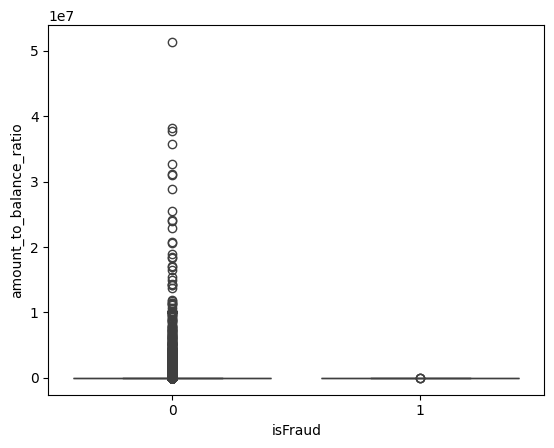

In [46]:
sns.boxplot(
    data=df.sample(100000),
    x='isFraud',
    y='amount_to_balance_ratio'
)

- The features contain substantial outliers, particularly among non-fraud transactions. Because the scale is dominated by these extrem values, the boxplot doesn't clearly reveal the central tendency differences between fraud and non-fraud transactions.

<Axes: xlabel='isFraud', ylabel='balancediff_Org_including_amount'>

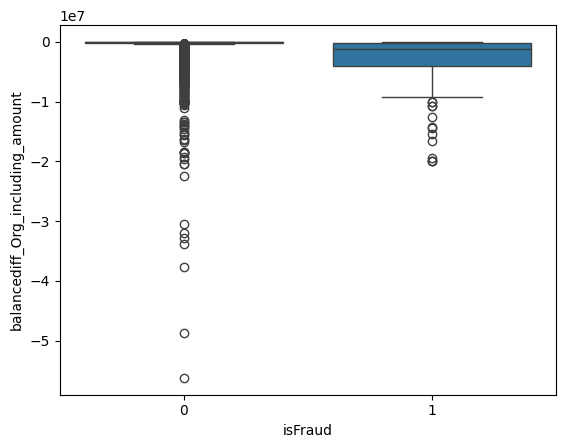

In [47]:
sns.boxplot(
    data=df.sample(100000),
    x = 'isFraud',
    y = 'balancediff_Org_including_amount'
)

- The feature balancediff_Org_including_amount was engineered to capture inconsistencies between the expected sender balance after a transaction and the actual recorded balance. The boxplot shows that fraudulent transactions exhibit substantially negative discrepencies compared to legitimate transactions.The fraud distribution is shifted downward and exhibits greater variability, suggesting that balance inconsistencies are strongly associated with fraudulent activities.

## Data Preprocessing

# MODEL A

In [48]:
df = df.drop(['nameOrig', 'nameDest'], axis = 1)

In [49]:
df = pd.get_dummies(df, columns=['type'], drop_first= True)

In [50]:
features = [
    'step',
    'type_CASH_OUT',
    'type_DEBIT',
    'type_PAYMENT',
    'type_TRANSFER',
    'amount',
    'oldbalanceOrg',
    'newbalanceOrig',
    'oldbalanceDest',
    'newbalanceDest',
    'balancediff_Dest_including_amount',
    'balancediff_Org_including_amount',
    'amount_to_balance_ratio',
    'is_zero_balance'
]

In [51]:
X = df[features]
y = df['isFraud']

In [52]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.2, random_state = 42, stratify = y)

In [53]:
scalar = StandardScaler()
X_train_scaled = scalar.fit_transform(X_train)
X_test_scaled = scalar.transform(X_test)

In [54]:
X_train_scaled.shape

(5090096, 14)

In [55]:
X_test_scaled.shape

(1272524, 14)

In [56]:
y_train.shape

(5090096,)

In [57]:
y_test.shape

(1272524,)

In [58]:
y_train.value_counts(normalize = True) * 100

0   99.87
1    0.13
Name: isFraud, dtype: float64

In [59]:
y_test.value_counts(normalize = True) * 100

0   99.87
1    0.13
Name: isFraud, dtype: float64

In [60]:
models = {
    'Logistic Regression': LogisticRegression(class_weight='balanced', random_state=42),
    'Random Forest': RandomForestClassifier(n_estimators=100, class_weight='balanced',random_state=42),
    'XGBoost': XGBClassifier(scale_pos_weight=4, random_state=42)
}

In [61]:
results = []

for name, model in models.items():

  if name in ("Random Forest", "XGBoost"):

    model.fit(X_train, y_train)
    y_preds = model.predict(X_test)
  else:

    model.fit(X_train_scaled, y_train)
    y_preds = model.predict(X_test_scaled)

  accuracy = accuracy_score(y_test, y_preds)
  recall = recall_score(y_test, y_preds)
  precision = precision_score(y_test, y_preds)
  f1 = f1_score(y_test, y_preds)

 # Getting the results
  results.append([name,accuracy,recall,precision,f1])

 # printing all the report parameters


  print(f"{name}")

  print("Accuracy:", accuracy)
  print("Recall:", recall)
  print("Precision:", precision)
  print("F1 Score :", f1)


  print('n\Classification Report\n')

  print(classification_report(y_test, y_preds))

  print('n\Confusion Matrix\n')

  print(confusion_matrix(y_test, y_preds))




results_df = pd.DataFrame(results, columns = ["Model", "Accuracy", "Recall", "Precision", "F1 Score"])

print("FINAL RESULTS TABLE")

print(results_df)

Logistic Regression
Accuracy: 0.9386306270058561
Recall: 0.970785149117468
Precision: 0.020027372835599754
F1 Score : 0.03924511588996604
n\Classification Report

              precision    recall  f1-score   support

           0       1.00      0.94      0.97   1270881
           1       0.02      0.97      0.04      1643

    accuracy                           0.94   1272524
   macro avg       0.51      0.95      0.50   1272524
weighted avg       1.00      0.94      0.97   1272524

n\Confusion Matrix

[[1192835   78046]
 [     48    1595]]
Random Forest
Accuracy: 0.9999968566408177
Recall: 0.9975654290931223
Precision: 1.0
F1 Score : 0.9987812309567337
n\Classification Report

              precision    recall  f1-score   support

           0       1.00      1.00      1.00   1270881
           1       1.00      1.00      1.00      1643

    accuracy                           1.00   1272524
   macro avg       1.00      1.00      1.00   1272524
weighted avg       1.00      1.00      

In [62]:
coef_df = pd.DataFrame({
    'Feature': X_train.columns,
    'Coefficient': models['Logistic Regression'].coef_[0]
})

coef_df.sort_values(
    by='Coefficient',
    ascending=False
)

,Feature,Coefficient
1,type_CASH_OUT,11.10
4,type_TRANSFER,6.86
12,amount_to_balance_ratio,5.27
6,oldbalanceOrg,3.95
8,oldbalanceDest,1.69
0,step,0.35
2,type_DEBIT,-0.47
3,type_PAYMENT,-1.72
13,is_zero_balance,-1.85
9,newbalanceDest,-1.92


In [63]:
feature_importance_xgb = pd.DataFrame({
                     'Feature': X_train.columns,
                     'Importance': models['XGBoost'].feature_importances_
})

feature_importance_xgb.sort_values(
    by = 'Importance',
    ascending = False,
    inplace = True
)

feature_importance_xgb.head(10)


,Feature,Importance
7,newbalanceOrig,0.50
12,amount_to_balance_ratio,0.22
11,balancediff_Org_including_amount,0.08
1,type_CASH_OUT,0.06
3,type_PAYMENT,0.04
4,type_TRANSFER,0.04
9,newbalanceDest,0.03
13,is_zero_balance,0.01
10,balancediff_Dest_including_amount,0.01
0,step,0.00


In [64]:
feature_importance_rf = pd.DataFrame({
                   'Feature': X_train.columns,
                   'Importance': models['Random Forest'].feature_importances_
})

feature_importance_rf.sort_values(
    by = 'Importance',
    ascending = False,
    inplace = True

)

feature_importance_rf.head(10)

,Feature,Importance
12,amount_to_balance_ratio,0.36
11,balancediff_Org_including_amount,0.15
7,newbalanceOrig,0.13
6,oldbalanceOrg,0.11
5,amount,0.06
4,type_TRANSFER,0.04
0,step,0.03
3,type_PAYMENT,0.03
1,type_CASH_OUT,0.02
13,is_zero_balance,0.02


- Feature importance analysis has revealed that balance related variables were the dominant predictors of fraud.
- Across Random Forest and XGboost, features such as amount_to_balance_ratio, 	balancediff_Org_including_amount and newbalanceOrig	contributed most strongly to model performance.
- This suggests that fraudulent transactions frequently involve draining the large proportion of the account balance, which aligns with the patterns observed in the eda.

In [65]:
results_models = []

for name, model in models.items():
  train_pred = model.predict(X_train)
  test_pred = model.predict(X_test)

  results_models.append({
      "Models": name,
      "F1_score_train": f1_score(y_train, train_pred),
      "F1_score_test":  f1_score(y_test, test_pred),
      "Gap": f1_score(y_train, train_pred) - f1_score(y_test, test_pred)
      })

df_check = pd.DataFrame(results_models)
print(df_check)

                Models  F1_score_train  F1_score_test   Gap
0  Logistic Regression            0.01           0.01 -0.00
1        Random Forest            1.00           1.00  0.00
2              XGBoost            0.97           0.93  0.04


### Checking for randomized search

In [66]:
from sklearn.model_selection import RandomizedSearchCV
from xgboost import XGBClassifier

param_dist = {

    'max_depth':[3,4,5,6]
}

xgb = XGBClassifier(
    random_state=42,
    scale_pos_weight=4
)

search = RandomizedSearchCV(estimator=xgb, param_distributions=param_dist, n_iter=10, scoring='f1', cv=3, verbose=2, n_jobs=-1, random_state=42
)

search.fit(X_train, y_train)

print(search.best_params_)
print(search.best_score_)

Fitting 3 folds for each of 4 candidates, totalling 12 fits
[CV] END ........................................max_depth=3; total time= 2.8min
[CV] END ........................................max_depth=3; total time= 2.8min
[CV] END ........................................max_depth=3; total time= 2.8min
[CV] END ........................................max_depth=4; total time= 3.0min
[CV] END ........................................max_depth=4; total time= 3.0min
[CV] END ........................................max_depth=4; total time= 3.0min
[CV] END ........................................max_depth=5; total time= 3.0min
[CV] END ........................................max_depth=5; total time= 3.1min
[CV] END ........................................max_depth=5; total time= 1.3min
[CV] END ........................................max_depth=6; total time= 1.3min
[CV] END ........................................max_depth=6; total time= 1.4min
[CV] END ........................................

In [67]:
from sklearn.model_selection import RandomizedSearchCV
from xgboost import XGBClassifier

param_dist = {

    'learning_rate':[0.05,0.1],
    'n_estimators':[100,200,300]
}

xgb = XGBClassifier(
    random_state=42,
    scale_pos_weight=4
)

search = RandomizedSearchCV(estimator=xgb, param_distributions=param_dist, n_iter=10, scoring='f1', cv=3, verbose=2, n_jobs=-1, random_state=42
)

search.fit(X_train, y_train)

print(search.best_params_)
print(search.best_score_)

Fitting 3 folds for each of 6 candidates, totalling 18 fits
[CV] END ...............learning_rate=0.05, n_estimators=100; total time= 5.5min
[CV] END ...............learning_rate=0.05, n_estimators=100; total time= 5.5min
[CV] END ...............learning_rate=0.05, n_estimators=100; total time= 5.5min
[CV] END ...............learning_rate=0.05, n_estimators=200; total time= 8.5min
[CV] END ...............learning_rate=0.05, n_estimators=200; total time= 8.7min
[CV] END ...............learning_rate=0.05, n_estimators=200; total time= 8.8min
[CV] END ................learning_rate=0.1, n_estimators=100; total time= 3.9min
[CV] END ................learning_rate=0.1, n_estimators=100; total time= 4.1min
[CV] END ...............learning_rate=0.05, n_estimators=300; total time=11.0min
[CV] END ...............learning_rate=0.05, n_estimators=300; total time=11.4min
[CV] END ................learning_rate=0.1, n_estimators=100; total time= 3.8min
[CV] END ...............learning_rate=0.05, n_est

- Hyperparameter tuning of learning_rate and n_estimators did not produce a meaningful impact on the original model.
- The baseline XGBoost model was already performing close to it's optimal configuration and the tested parameter combinations resulted in only marginal differences in F1 score.


### Threshold Tuning for XGBoost

In [68]:
y_probs = models['XGBoost'].predict_proba(X_test)[:,1]

In [69]:
y_probs.shape

(1272524,)

In [70]:
thresholds = [0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8]

results = []

for threshold in thresholds:
  y_predt = (y_probs >= threshold).astype(int)
  precision = precision_score(y_test, y_predt)
  recall = recall_score(y_test, y_predt)
  f1 = f1_score(y_test, y_predt)

  results.append([

              threshold,
              precision,
              recall,
              f1

  ])

threshold_df  = pd.DataFrame(results, columns=['threshold', 'precision', 'recall', 'f1'])
print(threshold_df)

   threshold  precision  recall   f1
0       0.10       0.77    0.99 0.87
1       0.20       0.82    0.99 0.90
2       0.30       0.85    0.98 0.91
3       0.40       0.88    0.97 0.92
4       0.50       0.91    0.96 0.93
5       0.60       0.93    0.95 0.94
6       0.70       0.95    0.94 0.94
7       0.80       0.96    0.92 0.94


In [71]:
threshold_df.sort_values(by = 'f1', ascending = False).head()

,threshold,precision,recall,f1
6,0.70,0.95,0.94,0.94
5,0.60,0.93,0.95,0.94
7,0.80,0.96,0.92,0.94
4,0.50,0.91,0.96,0.93
3,0.40,0.88,0.97,0.92


- Threshold tuning was performed on the XGBoost model to evaluate the trade-off between precision and recall.
- As the threshold increased the precision improved while recall decreased, demonstrating the expected classification trade-off.
- The threshold remained relatively stable for the f1 across thresholds of 0.6 to 0.8 indicating that model's probability estimate were well separated.
- From the above observations the threshold of 0.7 is selected where precision = 95%, recall = 94%, f1 = 94%.


## AUC-ROC Curve

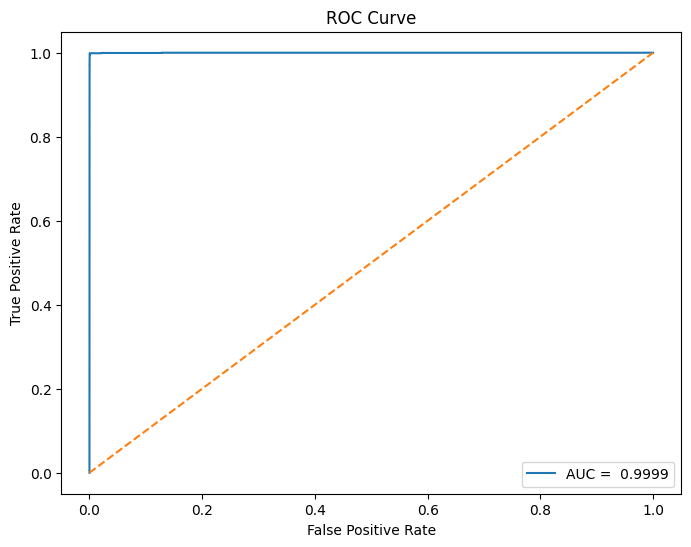

In [72]:
from sklearn.metrics import roc_curve
from sklearn.metrics import roc_auc_score


fpr, tpr, thresholds = roc_curve(
    y_test,
    y_probs
)

auc_score = roc_auc_score(
    y_test,
    y_probs
)

plt.figure(figsize=(8,6))

plt.plot(fpr,
         tpr,
         label = f'AUC = {auc_score: .4f}'
)

plt.plot(
     [0,1],
     [0,1],
     linestyle = '--'
)

plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve')


plt.legend()
plt.show()

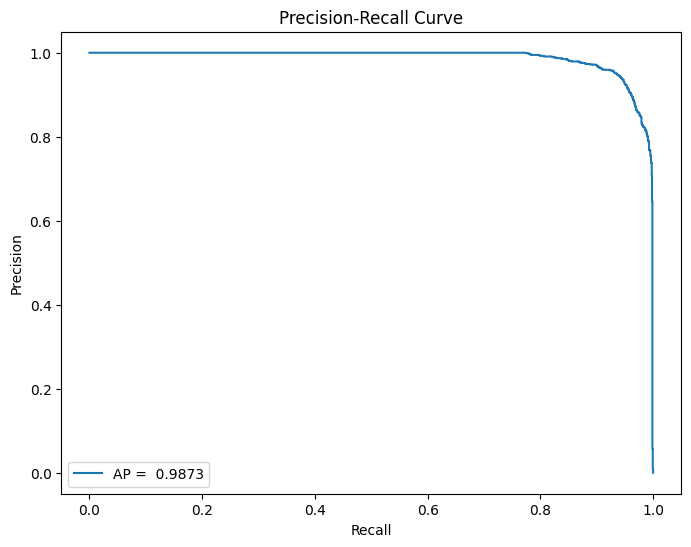

In [73]:
from sklearn.metrics import precision_recall_curve
from sklearn.metrics import average_precision_score


precision, recall, thresholds = (
    precision_recall_curve(
    y_test,
    y_probs
    )
)

ap_score = average_precision_score(
    y_test,
    y_probs
)

plt.figure(figsize=(8,6))

plt.plot(recall,
         precision,
         label = f'AP = {ap_score: .4f}'
)



plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Precision-Recall Curve')


plt.legend()
plt.show()

In [74]:
from sklearn.model_selection import cross_val_score
from sklearn.model_selection import StratifiedKFold


cv = StratifiedKFold(
    n_splits=3,
    shuffle=True,
    random_state=42
)

scores = cross_val_score(
    xgb,
    X_train,
    y_train,
    cv=cv,
    scoring='f1',
    n_jobs=-1
)

print(scores)
print("Mean F1:", scores.mean())
print("Std F1:", scores.std())

[0.92844284 0.92608213 0.9052537 ]
Mean F1: 0.9199262265950905
Std F1: 0.01041970631514559


### Error Analysis

In [75]:
y_pred = (y_probs > 0.7).astype(int)

In [76]:
fp_mask = (y_test == 0) & (y_pred == 1)

false_positives = X_test[fp_mask]
false_positives.shape


(86, 14)

In [77]:
false_positives.head()

,step,type_CASH_OUT,type_DEBIT,type_PAYMENT,type_TRANSFER,amount,oldbalanceOrg,newbalanceOrig,oldbalanceDest,newbalanceDest,balancediff_Dest_including_amount,balancediff_Org_including_amount,amount_to_balance_ratio,is_zero_balance
3166954,237,1,0,0,0,"114,187.56","113,884.00",0.00,"27,695.95","141,883.51",0.00,"-228,071.56",1.00,0
700025,37,1,0,0,0,"481,541.26","479,183.01",0.00,"3,577,041.95","4,499,056.40","440,473.19","-960,724.27",1.00,0
1036284,94,1,0,0,0,"21,427.76","21,375.00",0.00,"149,143.87","170,571.63",0.00,"-42,802.76",1.00,0
6192044,571,1,0,0,0,"251,034.47","250,145.00",0.00,0.00,"251,034.47",0.00,"-501,179.47",1.00,0
2816875,225,1,0,0,0,"224,198.88","224,129.46",0.00,"268,615.12","492,814.01",0.01,"-448,328.34",1.00,0


In [78]:
fn_mask = (y_test == 1) & (y_pred == 0)

false_negatives = X_test[fn_mask]
false_negatives.shape

(104, 14)

In [79]:
false_negatives.head()

,step,type_CASH_OUT,type_DEBIT,type_PAYMENT,type_TRANSFER,amount,oldbalanceOrg,newbalanceOrig,oldbalanceDest,newbalanceDest,balancediff_Dest_including_amount,balancediff_Org_including_amount,amount_to_balance_ratio,is_zero_balance
819544,40,1,0,0,0,"212,613.29","212,613.29",0.00,"1,370,788.41","1,583,401.69",-0.01,"-425,226.58",1.00,0
146628,12,1,0,0,0,"19,472.00","19,472.00",0.00,0.00,"19,472.00",0.00,"-38,944.00",1.00,0
5555690,383,1,0,0,0,"150,406.91","150,406.91",0.00,"1,903,051.04","2,053,457.95",0.00,"-300,813.82",1.00,0
854857,41,1,0,0,0,"32,690.68","32,690.68",0.00,"2,361,188.10","2,393,878.78",-0.00,"-65,381.36",1.00,0
3717512,278,1,0,0,0,"89,303.18","89,303.18",0.00,"131,088.75","220,391.93",0.00,"-178,606.36",1.00,0


In [80]:
false_positives.describe()

,step,type_CASH_OUT,type_DEBIT,type_PAYMENT,type_TRANSFER,amount,oldbalanceOrg,newbalanceOrig,oldbalanceDest,newbalanceDest,balancediff_Dest_including_amount,balancediff_Org_including_amount,amount_to_balance_ratio,is_zero_balance
count,86.00,86.00,86.00,86.00,86.00,86.00,86.00,86.00,86.00,86.00,86.00,86.00,86.00,86.00
mean,362.30,0.99,0.00,0.00,0.01,"185,764.17","178,766.02",50.88,"630,717.52","824,399.95","7,918.26","-364,479.31","6,432.26",0.01
std,199.54,0.11,0.00,0.00,0.11,"163,308.37","158,905.90",98.92,"2,148,181.09","2,199,277.76","53,847.66","316,712.48","59,641.07",0.11
min,2.00,0.00,0.00,0.00,0.00,"1,390.62",0.00,0.00,0.00,"3,271.33",-0.01,"-1,387,883.25",0.98,0.00
25%,225.50,1.00,0.00,0.00,0.00,"59,296.67","52,287.75",0.00,0.00,"138,387.41",0.00,"-533,464.21",1.00,0.00
50%,354.50,1.00,0.00,0.00,0.00,"136,170.48","133,692.02",0.00,"81,735.95","305,643.80",0.00,"-271,873.00",1.00,0.00
75%,539.50,1.00,0.00,0.00,0.00,"266,987.40","255,812.22",52.29,"338,170.15","623,701.53",0.00,"-118,433.92",1.01,0.00
max,715.00,1.00,0.00,0.00,1.00,"695,156.64","692,726.61",393.40,"16,485,611.15","17,023,775.96","440,473.19","-2,781.24","553,089.55",1.00


In [81]:
false_negatives.describe()

,step,type_CASH_OUT,type_DEBIT,type_PAYMENT,type_TRANSFER,amount,oldbalanceOrg,newbalanceOrig,oldbalanceDest,newbalanceDest,balancediff_Dest_including_amount,balancediff_Org_including_amount,amount_to_balance_ratio,is_zero_balance
count,104.00,104.00,104.00,104.00,104.00,104.00,104.00,104.00,104.00,104.00,104.00,104.00,104.00,104.00
mean,235.44,0.96,0.00,0.00,0.04,"132,471.11","127,406.49",0.00,"1,442,353.83","1,579,454.90","4,629.97","-259,877.60","4,645.12",0.03
std,164.23,0.19,0.00,0.00,0.19,"115,952.51","116,669.75",0.00,"2,798,022.81","2,914,737.68","152,464.57","230,314.77","32,469.77",0.17
min,8.00,0.00,0.00,0.00,0.00,119.00,0.00,0.00,0.00,0.00,"-395,219.27","-1,043,972.58",1.00,0.00
25%,112.25,1.00,0.00,0.00,0.00,"39,263.56","33,794.90",0.00,"20,145.49","130,931.04",-0.00,"-374,711.40",1.00,0.00
50%,233.50,1.00,0.00,0.00,0.00,"93,131.67","83,154.76",0.00,"410,275.79","476,131.43",0.00,"-181,779.05",1.00,0.00
75%,349.50,1.00,0.00,0.00,0.00,"195,247.81","187,355.70",0.00,"1,299,634.04","1,542,617.73",0.00,"-78,527.12",1.00,0.00
max,686.00,1.00,0.00,0.00,1.00,"521,986.29","521,986.29",0.00,"18,047,571.21","19,642,021.17","1,400,742.98",-238.00,"277,970.88",1.00


In [82]:
X_test.describe()

,step,type_CASH_OUT,type_DEBIT,type_PAYMENT,type_TRANSFER,amount,oldbalanceOrg,newbalanceOrig,oldbalanceDest,newbalanceDest,balancediff_Dest_including_amount,balancediff_Org_including_amount,amount_to_balance_ratio,is_zero_balance
count,"1,272,524.00","1,272,524.00","1,272,524.00","1,272,524.00","1,272,524.00","1,272,524.00","1,272,524.00","1,272,524.00","1,272,524.00","1,272,524.00","1,272,524.00","1,272,524.00","1,272,524.00","1,272,524.00"
mean,243.54,0.35,0.01,0.34,0.08,"179,671.22","834,435.98","855,783.83","1,101,974.62","1,225,808.09","-55,837.75","-158,323.37","70,610.05",0.33
std,142.38,0.48,0.08,0.47,0.28,"609,427.84","2,890,807.38","2,926,695.84","3,381,787.34","3,662,988.09","444,945.34","641,109.96","516,636.26",0.47
min,1.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,"-10,000,000.00","-73,823,490.36",0.00,0.00
25%,156.00,0.00,0.00,0.00,0.00,"13,384.44",0.00,0.00,0.00,0.00,"-29,400.10","-164,305.27",0.23,0.00
50%,239.00,0.00,0.00,0.00,0.00,"74,996.96","14,193.92",0.00,"132,318.88","213,336.48","-3,526.27","-25,105.21",6.45,0.00
75%,335.00,1.00,0.00,1.00,0.00,"208,857.81","107,238.00","144,626.61","942,483.82","1,109,462.62",0.00,"-1,985.81","12,270.48",1.00
max,743.00,1.00,1.00,1.00,1.00,"73,823,490.36","43,686,616.33","43,673,802.21","327,963,024.02","328,194,464.92","75,549,141.11",0.01,"73,823,490.36",1.00


In [83]:
tp_mask = (y_test == 1) & (y_pred == 1)

true_positives = X_test[tp_mask]

In [84]:
true_positives.describe()

,step,type_CASH_OUT,type_DEBIT,type_PAYMENT,type_TRANSFER,amount,oldbalanceOrg,newbalanceOrig,oldbalanceDest,newbalanceDest,balancediff_Dest_including_amount,balancediff_Org_including_amount,amount_to_balance_ratio,is_zero_balance
count,"1,539.00","1,539.00","1,539.00","1,539.00","1,539.00","1,539.00","1,539.00","1,539.00","1,539.00","1,539.00","1,539.00","1,539.00","1,539.00","1,539.00"
mean,371.02,0.45,0.00,0.00,0.55,"1,539,245.18","1,709,971.36","170,726.18","441,853.54","1,249,131.75","-731,966.97","-3,078,490.36",0.99,0.00
std,215.09,0.50,0.00,0.00,0.50,"2,460,476.96","3,420,477.69","1,659,788.43","1,762,937.85","2,815,916.23","1,820,438.89","4,920,953.93",0.07,0.04
min,1.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,"-10,000,000.00","-20,000,000.00",0.00,0.00
25%,184.50,0.00,0.00,0.00,0.00,"150,325.12","150,325.12",0.00,0.00,0.00,"-505,614.93","-3,276,079.49",1.00,0.00
50%,382.00,0.00,0.00,0.00,1.00,"482,679.60","482,679.60",0.00,0.00,0.00,"-35,063.63","-965,359.20",1.00,0.00
75%,559.50,1.00,0.00,0.00,1.00,"1,638,039.75","1,638,039.75",0.00,"92,487.90","983,629.21",0.00,"-300,650.25",1.00,0.00
max,743.00,1.00,0.00,0.00,1.00,"10,000,000.00","39,585,040.37","29,585,040.37","30,436,340.62","31,677,459.48","6,893,665.46",0.00,1.00,1.00


In [85]:
false_negatives.describe()

,step,type_CASH_OUT,type_DEBIT,type_PAYMENT,type_TRANSFER,amount,oldbalanceOrg,newbalanceOrig,oldbalanceDest,newbalanceDest,balancediff_Dest_including_amount,balancediff_Org_including_amount,amount_to_balance_ratio,is_zero_balance
count,104.00,104.00,104.00,104.00,104.00,104.00,104.00,104.00,104.00,104.00,104.00,104.00,104.00,104.00
mean,235.44,0.96,0.00,0.00,0.04,"132,471.11","127,406.49",0.00,"1,442,353.83","1,579,454.90","4,629.97","-259,877.60","4,645.12",0.03
std,164.23,0.19,0.00,0.00,0.19,"115,952.51","116,669.75",0.00,"2,798,022.81","2,914,737.68","152,464.57","230,314.77","32,469.77",0.17
min,8.00,0.00,0.00,0.00,0.00,119.00,0.00,0.00,0.00,0.00,"-395,219.27","-1,043,972.58",1.00,0.00
25%,112.25,1.00,0.00,0.00,0.00,"39,263.56","33,794.90",0.00,"20,145.49","130,931.04",-0.00,"-374,711.40",1.00,0.00
50%,233.50,1.00,0.00,0.00,0.00,"93,131.67","83,154.76",0.00,"410,275.79","476,131.43",0.00,"-181,779.05",1.00,0.00
75%,349.50,1.00,0.00,0.00,0.00,"195,247.81","187,355.70",0.00,"1,299,634.04","1,542,617.73",0.00,"-78,527.12",1.00,0.00
max,686.00,1.00,0.00,0.00,1.00,"521,986.29","521,986.29",0.00,"18,047,571.21","19,642,021.17","1,400,742.98",-238.00,"277,970.88",1.00


In [86]:
false_negatives['amount_to_balance_ratio'].describe()

count       104.00
mean      4,645.12
std      32,469.77
min           1.00
25%           1.00
50%           1.00
75%           1.00
max     277,970.88
Name: amount_to_balance_ratio, dtype: float64

In [87]:
true_positives['amount_to_balance_ratio'].describe()

count   1,539.00
mean        0.99
std         0.07
min         0.00
25%         1.00
50%         1.00
75%         1.00
max         1.00
Name: amount_to_balance_ratio, dtype: float64

## Model Saving

In [88]:
import joblib

# Save model
joblib.dump(
    models['XGBoost'],
    'xgboost_fraud_model.pkl'
)


['xgboost_fraud_model.pkl']

In [89]:
import joblib

loaded_model = joblib.load(
    'xgboost_fraud_model.pkl'
)

loaded_model.predict(X_test[:5])

array([0, 0, 0, 0, 0])

In [90]:
# Save chosen threshold
best_threshold = 0.7

joblib.dump(
    best_threshold,
    'fraud_threshold.pkl'
)

['fraud_threshold.pkl']

In [91]:
joblib.dump(
    X_train.columns.to_list(),
    "feature_columns.pkl"
)

['feature_columns.pkl']

In [92]:
def predict_fraud(transaction, model, threshold=0.7):

    prob = model.predict_proba(transaction)[:,1]

    prediction = (prob >= threshold).astype(int)

    return prediction

Using 1000 background data samples could cause slower run times. Consider using shap.sample(data, K) or shap.kmeans(data, K) to summarize the background as K samples.


  0%|          | 0/500 [00:00<?, ?it/s]

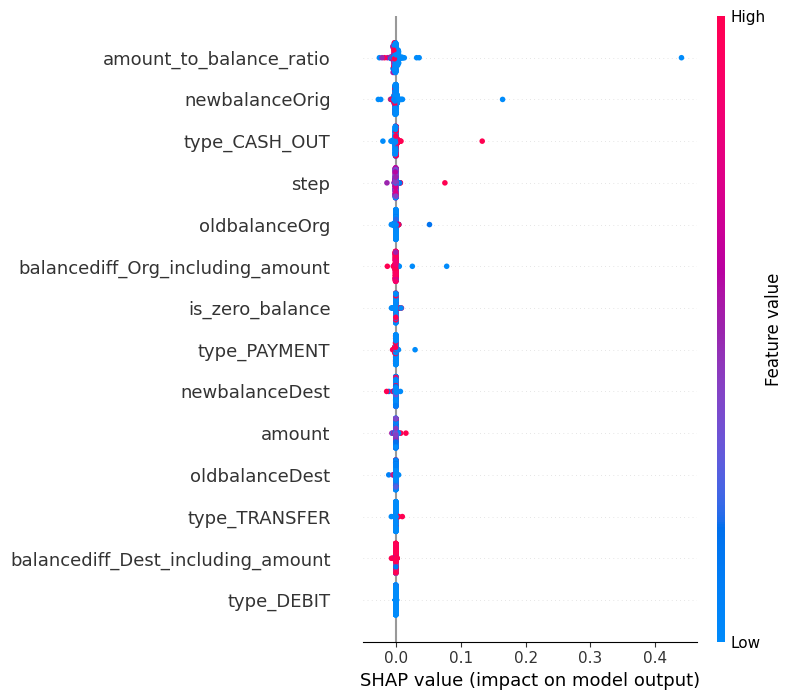

In [93]:
import shap

explainer = shap.KernelExplainer(
    lambda x: models['XGBoost'].predict(x),
    X_train[:1000].values
)

shap_values = explainer.shap_values(
    X_test[:500].values
)

shap.summary_plot(
    shap_values,
    X_test[:500]
)